# XAI-project — Robustez del label L2 al umbral EWE y a η_r

**Course:** INF-473 Explainable AI · UTFSM · Prof. Raquel Pezoa Rivera
**Authors:** Eduardo Morales · Octavia Jara · Benjamín Reyes

**Notebook:** `modeling/04_l2_threshold_sensitivity` — re-deriva el label L2 en memoria (FRP→FLI) sobre grids del umbral FLI y de la radiant fraction η_r, y mide la robustez del proxy L1→L2. Guarda `latex/images/l2_threshold_sensitivity.png` y muestra la figura inline.

> Requiere `data/processed/conaf_enriched_2012_2018.parquet`. Ver [`README.md`](../README.md).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from IPython.display import display

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import BASE_DIR, DATA_PROCESSED  # noqa: E402
from src.modeling_features import (  # noqa: E402
    FEATURE_COLS,
    MEGAFIRE_HA_THRESHOLD,
    N_SPLITS,
    RANDOM_STATE,
    STUDY_REGIONS,
    XGB_PARAMS,
)
from src.modis import (  # noqa: E402
    FLI_EWE_THRESHOLD_KW_M,
    MIN_AREA_HA_FOR_L2,
    MODIS_PIXEL_LENGTH_M,
    RADIANT_FRACTION,
)

DATA = DATA_PROCESSED / "conaf_enriched_2012_2018.parquet"
OUT_PNG = BASE_DIR / "latex" / "images" / "l2_threshold_sensitivity.png"

N_REPEATS = 5  # repeticiones de CV para estabilizar el OOF (menos que modeling/03, basta para la tendencia)

# Grids de sensibilidad (el resto de los supuestos se mantiene en su valor nominal).
FLI_GRID = [6000.0, 8000.0, 10000.0, 12000.0, 14000.0, 16000.0]
ETA_GRID = [0.10, 0.13, 0.15, 0.17, 0.20]


def load():
    """Carga 2012-2018 y prepara features, score-inputs de L2 y columnas usables.

    Replica el preprocesamiento de ``modeling/03`` (las constantes son la fuente
    única en ``src.modeling_features``), pero conserva además ``modis_frp_max_mw`` y
    la superficie para poder re-derivar el label L2 con distintos supuestos.

    Returns:
        Tupla ``(df, cols)`` con el DataFrame filtrado y la lista de features
        presentes y no totalmente nulas.
    """
    df = pd.read_parquet(DATA)
    df = df[df["region"].astype(str).isin(STUDY_REGIONS)].copy()
    ts = pd.to_datetime(df["fecha_hora_inicio"], errors="coerce")
    df["month"], df["hour"], df["day_of_year"] = ts.dt.month, ts.dt.hour, ts.dt.dayofyear
    for c in ["region", "provincia", "comuna"]:
        df[c] = pd.Categorical(df[c]).codes
    cols = [c for c in FEATURE_COLS if c in df.columns]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    cols = [c for c in cols if not df[c].isna().all()]
    df["label_l1"] = (df["superficie_quemada_total_ha"] >= MEGAFIRE_HA_THRESHOLD).astype(int)
    df = df.dropna(subset=["superficie_quemada_total_ha", "label_l2"] + cols).copy().reset_index(drop=True)
    return df, cols


def relabel_l2(frp_max, area, fli_threshold, eta_r):
    """Re-deriva el label L2 binario con un umbral FLI y una radiant fraction dados.

    Reproduce la regla de ``src.modis.label_l2`` (FRP→FLI peak-local + guardia de
    área) sin tocar el parquet: ``FLI = FRP_max · 1000 / η_r / L_p``.

    Args:
        frp_max: Serie de FRP máximo [MW] por evento (NaN si sin detección).
        area: Serie de superficie quemada [ha] por evento.
        fli_threshold: Umbral de FLI [kW/m] para marcar EWE.
        eta_r: Radiant fraction η_r usada en la conversión.

    Returns:
        Array binario (int) con el label L2 re-derivado.
    """
    frp = pd.to_numeric(frp_max, errors="coerce").to_numpy(dtype=float)
    fli = np.where(frp > 0, frp * 1000.0 / eta_r / MODIS_PIXEL_LENGTH_M, np.nan)
    area_ok = pd.to_numeric(area, errors="coerce").to_numpy(dtype=float) >= MIN_AREA_HA_FOR_L2
    return ((fli >= fli_threshold) & area_ok).astype(int)


def make_model(y):
    """Crea un XGBClassifier con ``scale_pos_weight`` ajustado a la clase rara."""
    spw = (len(y) - y.sum()) / max(y.sum(), 1)
    return xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw)


def repeated_oof(X, y):
    """Probabilidad OOF promediada sobre ``N_REPEATS`` particiones estratificadas.

    Args:
        X: Matriz de features.
        y: Vector de etiquetas binarias.

    Returns:
        Vector de probabilidad OOF promedio por muestra.
    """
    oof_sum = np.zeros(len(y))
    for rep in range(N_REPEATS):
        skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + rep)
        oof_sum += cross_val_predict(make_model(y), X, y, cv=skf, method="predict_proba", n_jobs=1)[:, 1]
    return oof_sum / N_REPEATS


def sweep(X, y_l1, oof_l1, frp_max, area, axis, grid, fixed_label):
    """Recorre un grid de un supuesto del label L2 y mide la robustez del proxy.

    Args:
        X: Matriz de features.
        y_l1: Etiqueta L1 (área), para el overlap.
        oof_l1: Score L1 OOF (fijo), para el AUC de proxy.
        frp_max: FRP máximo por evento.
        area: Superficie por evento.
        axis: ``"fli"`` o ``"eta"`` — qué supuesto se varía.
        grid: Valores a recorrer.
        fixed_label: Texto del supuesto que queda fijo (para el log).

    Returns:
        DataFrame con una fila por punto del grid y las métricas de robustez.
    """
    print(f"\n=== Sensibilidad por {axis} ({fixed_label}) ===")
    rows = []
    for v in grid:
        if axis == "fli":
            y2 = relabel_l2(frp_max, area, fli_threshold=v, eta_r=RADIANT_FRACTION)
        else:
            y2 = relabel_l2(frp_max, area, fli_threshold=FLI_EWE_THRESHOLD_KW_M, eta_r=v)
        n_pos = int(y2.sum())
        proxy_auc = roc_auc_score(y2, oof_l1) if 0 < n_pos < len(y2) else np.nan
        if n_pos >= N_SPLITS:
            oof_l2 = repeated_oof(X, y2)
            roc_l2 = roc_auc_score(y2, oof_l2)
            pr_l2 = average_precision_score(y2, oof_l2)
        else:
            roc_l2 = pr_l2 = np.nan
        overlap = int(((y2 == 1) & (y_l1 == 1)).sum())
        rows.append(dict(value=v, n_pos=n_pos, roc_l2=roc_l2, pr_l2=pr_l2,
                         proxy_auc=proxy_auc, overlap=overlap))
        print(f"  {axis}={v:<8} n_pos={n_pos:<3} ROC_L2={roc_l2:.3f}  "
              f"proxy_AUC={proxy_auc:.3f}  overlap={overlap}/{n_pos}")
    return pd.DataFrame(rows)


def _panel(ax, df, xlabel, baseline):
    """Dibuja un panel de sensibilidad: AUCs (eje izq) y nº de positivos (eje der)."""
    ax.plot(df["value"], df["proxy_auc"], "o-", color="#2c7fb8", label="AUC proxy (score L1→L2)")
    ax.plot(df["value"], df["roc_l2"], "s--", color="#c0392b", label="ROC-AUC propio L2")
    ax.axvline(baseline, color="#888", ls=":", lw=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("AUC")
    ax.set_ylim(0.5, 1.0)
    ax2 = ax.twinx()
    ax2.bar(df["value"], df["n_pos"], width=(df["value"].iloc[1] - df["value"].iloc[0]) * 0.25,
            color="#bbb", alpha=0.5, zorder=0)
    ax2.set_ylabel("nº positivos L2")
    return ax2

## Carga + score L1 OOF (fijo para el proxy)

In [2]:
print(f"Cargando {DATA.name}...")
df, cols = load()
X = df[cols].values
y_l1 = df["label_l1"].values.astype(int)
frp_max, area = df["modis_frp_max_mw"], df["superficie_quemada_total_ha"]
print(f"Filas: {len(df)} | L1 positivos: {y_l1.sum()}")

print("OOF L1 (score de área, fijo para el proxy)...")
oof_l1 = repeated_oof(X, y_l1)

Cargando conaf_enriched_2012_2018.parquet...
Filas: 30511 | L1 positivos: 76
OOF L1 (score de área, fijo para el proxy)...


## Barridos de sensibilidad (umbral FLI, η_r)

In [3]:
df_fli = sweep(X, y_l1, oof_l1, frp_max, area, "fli", FLI_GRID,
               fixed_label=f"η_r={RADIANT_FRACTION}")
df_eta = sweep(X, y_l1, oof_l1, frp_max, area, "eta", ETA_GRID,
               fixed_label=f"FLI={FLI_EWE_THRESHOLD_KW_M:.0f} kW/m")


=== Sensibilidad por fli (η_r=0.17) ===


  fli=6000.0   n_pos=22  ROC_L2=0.834  proxy_AUC=0.882  overlap=13/22


  fli=8000.0   n_pos=14  ROC_L2=0.888  proxy_AUC=0.860  overlap=9/14


  fli=10000.0  n_pos=11  ROC_L2=0.906  proxy_AUC=0.884  overlap=6/11


  fli=12000.0  n_pos=7   ROC_L2=0.809  proxy_AUC=0.884  overlap=3/7


...

  eta=0.1      n_pos=22  ROC_L2=0.834  proxy_AUC=0.882  overlap=13/22


  eta=0.13     n_pos=14  ROC_L2=0.888  proxy_AUC=0.860  overlap=9/14


  eta=0.15     n_pos=13  ROC_L2=0.853  proxy_AUC=0.882  overlap=8/13


  eta=0.17     n_pos=11  ROC_L2=0.906  proxy_AUC=0.884  overlap=6/11


  eta=0.2      n_pos=7   ROC_L2=0.809  proxy_AUC=0.884  overlap=3/7


## Figura — guardada en `latex/images/` + mostrada inline

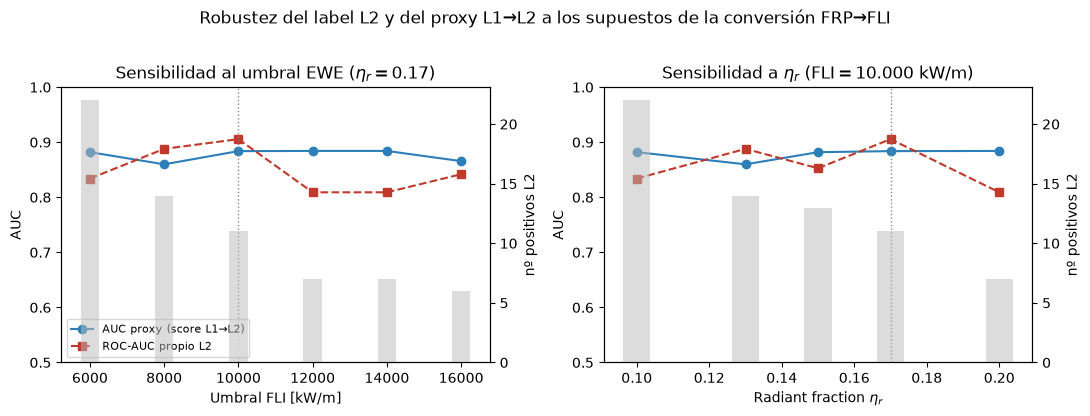


✅ Figura: /home/imorales/Desktop/XAI/XAI-project/latex/images/l2_threshold_sensitivity.png


In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
_panel(axL, df_fli, "Umbral FLI [kW/m]", FLI_EWE_THRESHOLD_KW_M)
ax2 = _panel(axR, df_eta, r"Radiant fraction $\eta_r$", RADIANT_FRACTION)
axL.set_title(r"Sensibilidad al umbral EWE ($\eta_r=0.17$)")
axR.set_title(r"Sensibilidad a $\eta_r$ (FLI$=$10.000 kW/m)")
axL.legend(loc="lower left", fontsize=8)
fig.suptitle("Robustez del label L2 y del proxy L1→L2 a los supuestos de la conversión FRP→FLI")
fig.tight_layout(rect=(0, 0, 1, 0.96))
OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_PNG, dpi=130, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"\n✅ Figura: {OUT_PNG}")